In [1]:
import numpy as np
# import cupy as cp
import matplotlib.pyplot as plt
# from cupyx.scipy.signal import fftconvolve
import pyvista as pv

In [2]:
%config InlineBackend.figure_format = 'retina'
plt.set_cmap('gray')

<Figure size 640x480 with 0 Axes>

### 3D box spline visualization

In [4]:
N = 100
L = 1.5
x = cp.linspace(-L, L, N)
y = cp.linspace(-L, L, N)
z = cp.linspace(-L, L, N)
X, Y, Z = cp.meshgrid(x, y, z, indexing='ij')
V = cp.zeros((N, N, N))

NameError: name 'cp' is not defined

In [5]:
# Cube 3D
V += ((cp.abs(X) <= 0.5) & (cp.abs(Y) <= 0.5) & (cp.abs(Z) <= 0.5)).astype(cp.float32)

float32


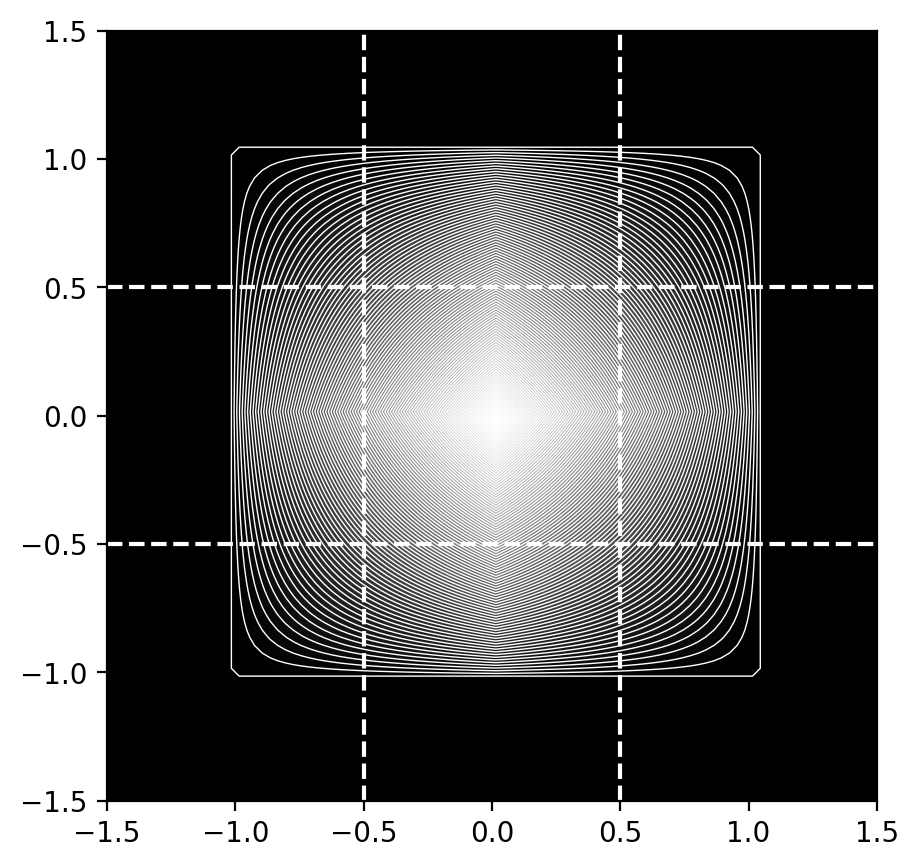

In [6]:
# box1 is the convolution between V and V
Box1 = cp.array(fftconvolve(V, V, mode='same'), dtype=cp.float32)
print(Box1.dtype)
visualize = "slice"

if visualize == "volume":
    pv.OFF_SCREEN = False
    pv.set_jupyter_backend("trame")
    vol = cp.asnumpy(Box1).astype(np.float32)
    Nx, Ny, Nz = vol.shape

    grid = pv.ImageData()
    grid.dimensions = (Nx+1, Ny+1, Nz+1)      # cell-centered data ⇒ +1
    grid.origin = (-L, -L, -L)
    dx = 2*L/N
    grid.spacing = (dx, dx, dx)
    grid.cell_data["values"] = vol.ravel(order="F")   # VTK likes Fortran order

    p = pv.Plotter(notebook=True)
    p.add_volume(grid, cmap="gray", opacity="sigmoid_6", shade=True)
    img = p.screenshot(return_img=True)

    plt.imshow(img); plt.axis("off"); plt.show()

if visualize == "slice":
    plt.figure(figsize=(5, 5))
    # set to 0 with clamp
    Box1 = cp.where(Box1 < 1e-7, 0, Box1)
    plt.imshow(cp.asnumpy(Box1[:, :, N//2]), extent=(-L, L, -L, L))
    plt.contour(cp.asnumpy(Box1[:, :, N//2]), levels=100, colors='w', linewidths=0.5, extent=(-L, L, -L, L))

    plt.axhline(y=-0.5, color='white', linestyle='--')
    plt.axhline(y=0.5, color='white', linestyle='--')
    plt.axvline(x=-0.5, color='white', linestyle='--')
    plt.axvline(x=0.5, color='white', linestyle='--')
    plt.show()

## Create Xray projections

In [7]:
import xrt_toolkit as xtk

In [2]:
N_angle = 100
N_offset = N
N_side = N
N_depth = N
width = N

v_shape = Box1.shape

# Let's build the necessary components to instantiate the operator. ========================
angle = np.linspace(0, np.pi, N_angle, endpoint=False)
n = np.stack([np.cos(angle), np.sin(angle)], axis=1)
pitch = 1.0  

t = n[:, [1, 0]] * np.r_[-1, 1]

t_max = pitch * (N_side-1) / 2 * 1 
t_offset = np.linspace(-t_max, t_max, N_offset, endpoint=True)

n_spec = np.broadcast_to(n.reshape(N_angle, 1, 2), (N_angle, N_offset, 2))  # (N_angle, N_offset, 2)
t_spec = t.reshape(N_angle, 1, 2) * t_offset.reshape(N_offset, 1)  # (N_angle, N_offset, 2)

n_spec = np.broadcast_to(n_spec.reshape(N_angle, N_offset, 1, 2), (N_angle, N_offset, N_depth, 2))
n_spec = np.concatenate([n_spec, np.zeros((N_angle, N_offset, N_depth, 1))], axis=-1)

t_spec = np.broadcast_to(t_spec.reshape(N_angle, N_offset, 1, 2), (N_angle, N_offset, N_depth, 2))
t_spec = np.concatenate([t_spec, np.zeros((N_angle, N_offset, N_depth, 1))], axis=-1)
t_max = pitch * (N_depth-1) / 2 * 1  # 10% over ball radius
t_spec[:,:,:,2] = np.linspace(-t_max, t_max, N_depth, endpoint=True).reshape(1,1,N_depth) 

v_shape = v_shape[0], v_shape[1], v_shape[2]
t_spec += pitch * np.array([width/2, N_side/2, N_depth/2]) # Move anchor point to the center of volume. before 5*Nwidth/2

print('GPU conversion ...')

t_spec = cp.array(t_spec, dtype=cp.float32)
n_spec = cp.array(n_spec, dtype=cp.float32)

NameError: name 'N' is not defined

In [3]:
t_spec = t_spec.reshape(-1, 3)
n_spec = n_spec.reshape(-1, 3)
N_ray = max(len(t_spec), len(n_spec))
ray_spec = (xtk.asarray(t_spec), xtk.asarray(n_spec))
knot_spec = xtk.UniformSpec(start=0, step=(1, 1, 1), num=(N, N ,N))

vol = xtk.asarray(Box1.reshape(-1))
proj_dr = xtk.xrt_apply(ray_spec, knot_spec, 0, vol)

NameError: name 't_spec' is not defined

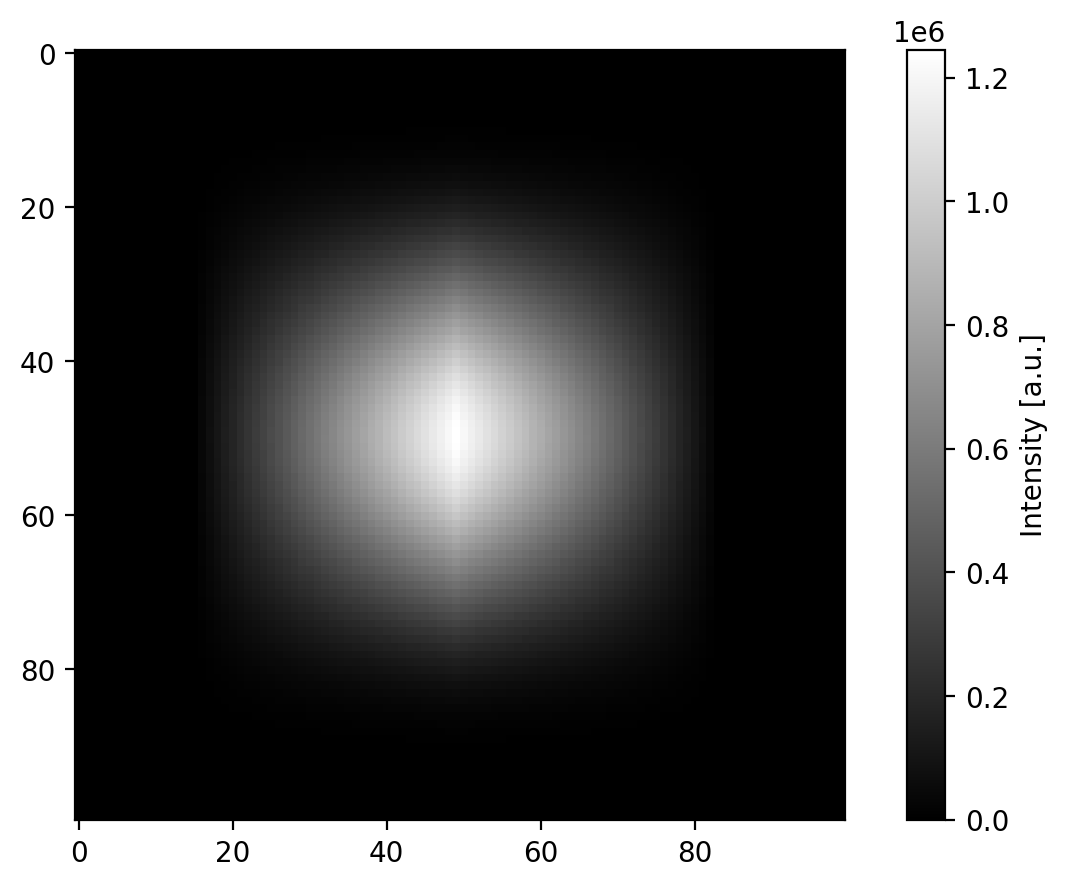

In [10]:
plt.figure(figsize=(8, 5))
pl = plt.imshow(cp.asnumpy(proj_dr).reshape(N_angle, N, N)[13])
plt.colorbar(pl, label='Intensity [a.u.]')
plt.show()

In [11]:
np.save('3D_boxsplines.npy', cp.asnumpy(proj_dr).reshape(N_angle, N, N))

## save as a dataset

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

import drjit as dr
import drjit.nn as dnn
from drjit.opt import Adam, GradScaler
from pathlib import Path
from drjit.llvm.ad import Float32 , Float16 , TensorXf16

In [ ]:
data = np.load('3D_boxsplines.npy')
data /= data.max()

NameError: name 'np' is not defined

In [4]:
# --- prepare training data ---
N = 100
L = 1.5
x_values = np.linspace(-L, L, N, dtype=np.float32)
y_values = np.linspace(-L, L, N, dtype=np.float32)
theta_values = np.linspace(0.0, np.pi, N, endpoint=False, dtype=np.float32)

print("Building training grid...")
XX, YY, TT = np.meshgrid(x_values, y_values, theta_values, indexing='ij')
x_flat = XX.ravel()
y_flat = YY.ravel()
theta_flat = TT.ravel()

sin_flat = np.sin(theta_flat).astype(np.float32)
cos_flat = np.cos(theta_flat).astype(np.float32)

def nearest_index(vals, grid):
    step = grid[1] - grid[0]
    return np.clip(np.round((vals - grid[0]) / step).astype(np.int64), 0, len(grid) - 1)

idx_theta = nearest_index(theta_flat, theta_values)
idx_y = nearest_index(y_flat, y_values)
idx_x = nearest_index(x_flat, x_values)
targets_np = data[idx_theta, idx_y, idx_x].astype(np.float32).reshape(-1, 1)

features_np = np.stack([
    x_flat.astype(np.float32),
    y_flat.astype(np.float32),
    sin_flat,
    cos_flat
], axis=1)

num_samples = features_np.shape[0]

Float = Float16
FloatAcc = Float32
UInt = dr.uint32_array_t(FloatAcc)

feature_components = [Float(features_np[:, i]) for i in range(features_np.shape[1])]
target_components = Float(targets_np[:, 0])
train_inputs = dnn.CoopVec(*feature_components)
train_targets = target_components
training_volume = targets_np.reshape(N, N, N)

rng_net = dr.rng(seed=0)
rng_batch = dr.rng(seed=1)

net = dnn.Sequential(
    dnn.Linear(4, 16),
    dnn.ReLU(),
    dnn.Linear(16, 16),
    dnn.ReLU(),
    dnn.Linear(16, 16),
    dnn.ReLU(),
    dnn.Linear(16, 16),
    dnn.ReLU(),
    dnn.Linear(16, 1)
)

net = net.alloc(dtype=TensorXf16, size=4, rng=rng_net)
weights, net = dnn.pack(net, layout='inference')

print("Starting training...")
optimizer = Adam(lr=1e-3, params=[weights])
scaler = GradScaler()

batch_size = 65536
num_epochs = 10
num_batches = int(np.ceil(num_samples / batch_size))

for epoch in range(num_epochs):
    perm = dr.randperm(UInt(num_samples), rng=rng_batch)

    for b in range(num_batches):
        batch_indices = perm[b * batch_size: (b + 1) * batch_size]
        batch_inputs = dnn.index(train_inputs, batch_indices)
        batch_targets = dr.index(train_targets, batch_indices)

        with dr.resume_grad():
            predictions, = net(batch_inputs, weights=weights)
            loss = dr.mean((predictions - batch_targets) ** 2)

        scaled_loss = scaler.scale(loss)
        grads = dr.grad(scaled_loss, weights)
        scaler.unscale_(optimizer, grads)
        optimizer.step(grads)
        scaler.update()

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss}")



Building training grid...
Starting training...


AttributeError: 'list' object has no attribute 'items'

In [23]:
weights[:] = Float16(opt['weights'])
weights_f32 = np.array(dr.detach(Float(opt['weights'])))
np.savez(weights_path, weights=weights_f32)
print(f"Saved weights to {weights_path.name}")


Saved weights to 3D_spline_weights.npz


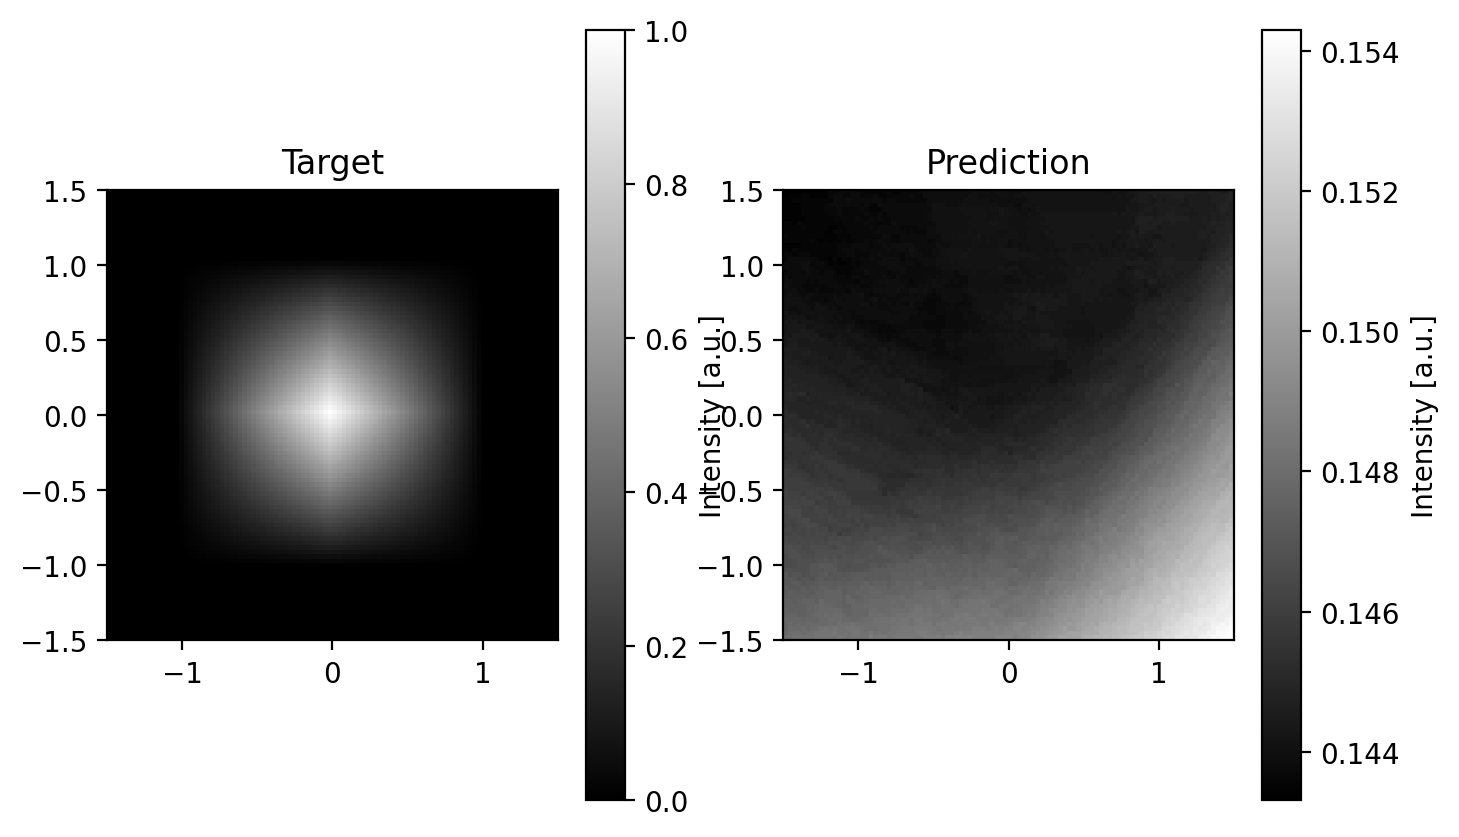

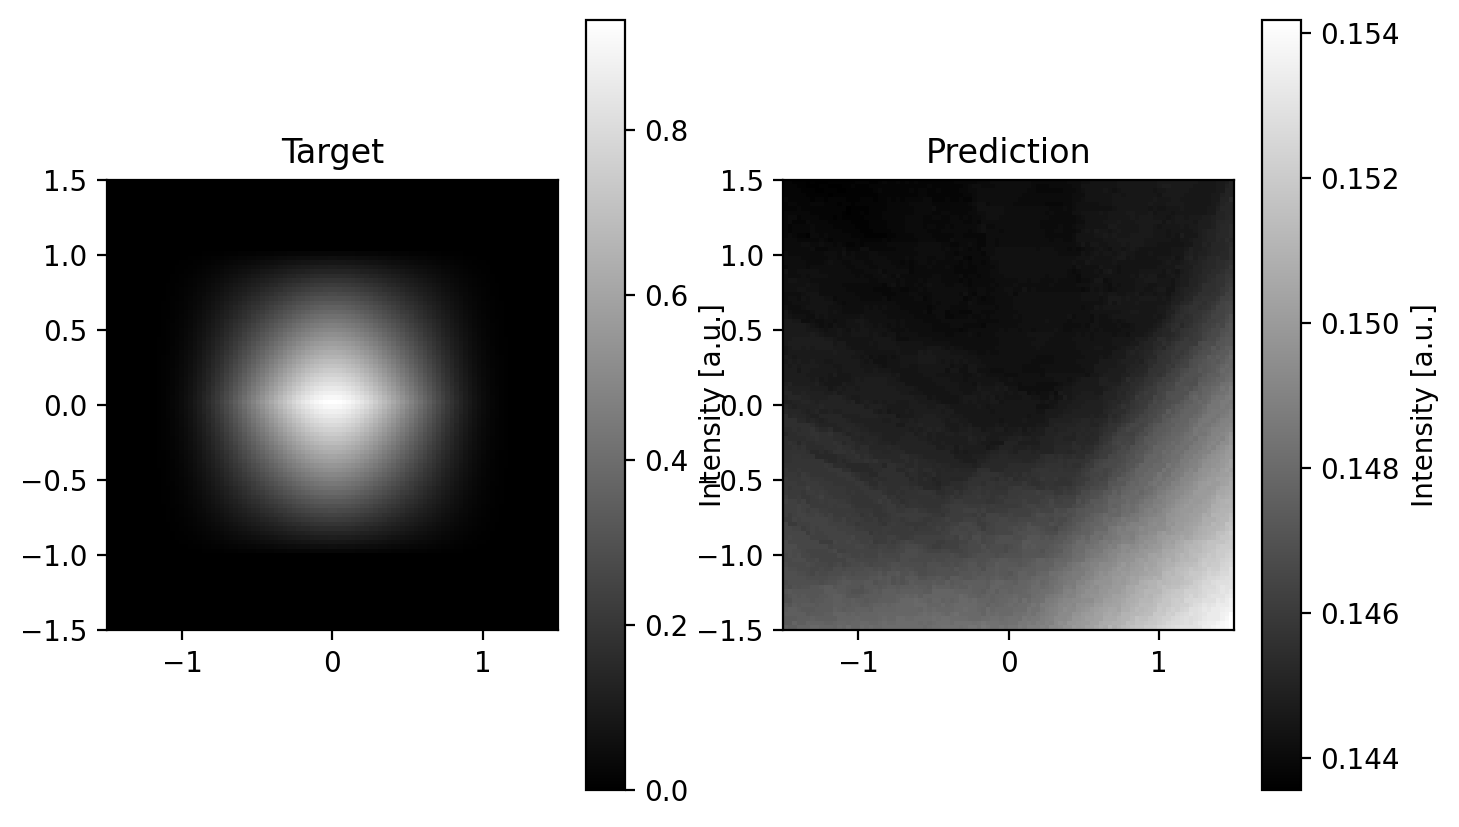

In [24]:
weights[:] = Float16(opt['weights'])

train_prediction = coop_to_float(net(train_inputs))
train_prediction_np = np.array(dr.detach(train_prediction)).reshape(N, N, N)

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.title('Target')
plt.imshow(training_volume[:, :, 0], extent=(-L, L, -L, L))
plt.colorbar(label='Intensity [a.u.]')
plt.subplot(1, 2, 2)
plt.title('Prediction')
plt.imshow(train_prediction_np[:, :, 0], extent=(-L, L, -L, L))
plt.colorbar(label='Intensity [a.u.]')
plt.show()

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.title('Target')
plt.imshow(training_volume[:, :, 12], extent=(-L, L, -L, L))
plt.colorbar(label='Intensity [a.u.]')
plt.subplot(1, 2, 2)
plt.title('Prediction')
plt.imshow(train_prediction_np[:, :, 12], extent=(-L, L, -L, L))
plt.colorbar(label='Intensity [a.u.]')
plt.show()


In [16]:
N_eval = 200
L_eval = 1.5
x_values_eval = np.linspace(-L_eval, L_eval, N_eval, dtype=np.float32)
y_values_eval = np.linspace(-L_eval, L_eval, N_eval, dtype=np.float32)
theta_values_eval = np.linspace(0.0, np.pi, N_eval, endpoint=False, dtype=np.float32)

print("Building evaluation grid...")
XX_eval, YY_eval, TT_eval = np.meshgrid(x_values_eval, y_values_eval, theta_values_eval, indexing='ij')
x_eval = XX_eval.ravel()
y_eval = YY_eval.ravel()
theta_eval = TT_eval.ravel()

sin_eval = np.sin(theta_eval).astype(np.float32)
cos_eval = np.cos(theta_eval).astype(np.float32)

def gather_targets(x_vals, y_vals, theta_vals):
    idx_theta = nearest_index(theta_vals, theta_values)
    idx_y = nearest_index(y_vals, y_values)
    idx_x = nearest_index(x_vals, x_values)
    return data[idx_theta, idx_y, idx_x].astype(np.float32)

targets_eval_np = gather_targets(x_eval, y_eval, theta_eval).reshape(-1, 1)

features_eval_np = np.stack([
    x_eval.astype(np.float32),
    y_eval.astype(np.float32),
    sin_eval,
    cos_eval
], axis=1)

evaluation_components = [Float(features_eval_np[:, i]) for i in range(features_eval_np.shape[1])]
evaluation_inputs = dnn.CoopVec(*evaluation_components)
evaluation_targets = targets_eval_np.reshape(N_eval, N_eval, N_eval)


Building evaluation grid...


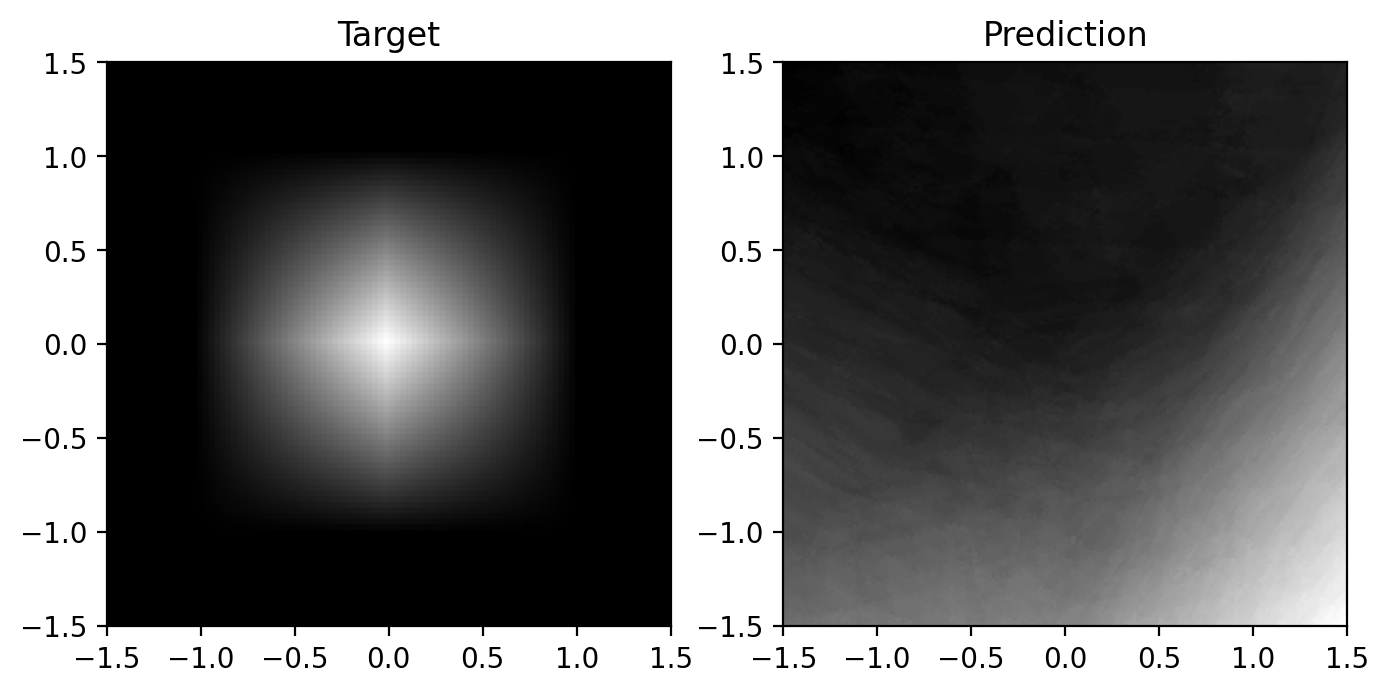

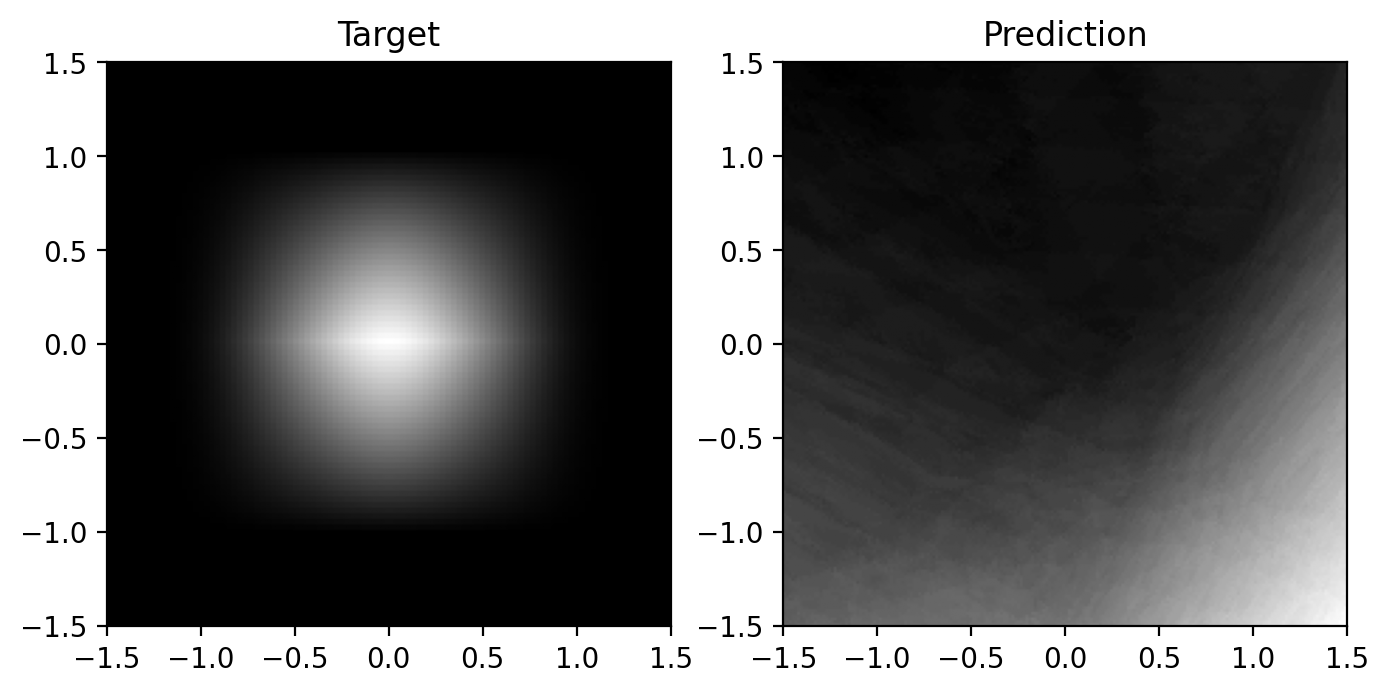

In [17]:
weights[:] = Float16(opt['weights'])

evaluation_prediction = coop_to_float(net(evaluation_inputs))
evaluation_pred_np = np.array(dr.detach(evaluation_prediction)).reshape(N_eval, N_eval, N_eval)

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.title('Target')
plt.imshow(evaluation_targets[:, :, 0], extent=(-L_eval, L_eval, -L_eval, L_eval))
plt.subplot(1, 2, 2)
plt.title('Prediction')
plt.imshow(evaluation_pred_np[:, :, 0], extent=(-L_eval, L_eval, -L_eval, L_eval))
plt.show()

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.title('Target')
plt.imshow(evaluation_targets[:, :, 25], extent=(-L_eval, L_eval, -L_eval, L_eval))
plt.subplot(1, 2, 2)
plt.title('Prediction')
plt.imshow(evaluation_pred_np[:, :, 25], extent=(-L_eval, L_eval, -L_eval, L_eval))
plt.show()
